In [4]:
import sys, os
os.chdir(os.path.dirname(os.path.abspath("__file__")))
sys.path.insert(0, "sudoku")

import numpy as np
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from argparse import Namespace
from torch.utils.data import DataLoader, TensorDataset, Subset
from models_sudoku import SingleOptLayerSudoku
from utils_sudoku import computeErr

sns.set_theme(style="whitegrid", context="talk")

In [5]:
METHOD = "ffocp_eq"
SEED = 1
N = 2
BATCH_SIZE = 8
LR = 0.1
EPOCHS = 1
DEVICE = torch.device("cpu")

In [6]:
def run_training(warm_start: bool):
    """Run one epoch of sudoku training. Returns per-iteration timing DataFrame."""
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    # Load data
    features = torch.load(f"sudoku/data/{N}/features.pt")
    labels = torch.load(f"sudoku/data/{N}/labels.pt")
    features = torch.tensor(features, dtype=torch.float32).to(DEVICE)
    labels = torch.tensor(labels, dtype=torch.float32).to(DEVICE)

    dataset = TensorDataset(features, labels)
    train_size = int(len(dataset) * 0.9)
    train_dataset = Subset(dataset, list(range(train_size)))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model = SingleOptLayerSudoku(
        N, learnable_parts=["eq"], layer_type=METHOD,
        Qpenalty=0.1, alpha=100, dual_cutoff=1e-3,
        slack_tol=1e-8, batch_size=BATCH_SIZE, warm_start=warm_start,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = torch.nn.MSELoss()

    records = []
    accum_fwd, accum_bwd = 0.0, 0.0

    model.train()
    for i, (x, y) in enumerate(train_loader):
        if i % 50 == 0:
            print(f"  iter {i}/{len(train_loader)}")

        t0 = time.time()
        pred = model(x)
        loss = loss_fn(pred, y)
        fwd_time = time.time() - t0

        t0 = time.time()
        loss.backward()
        bwd_time = time.time() - t0

        optimizer.step()
        optimizer.zero_grad()

        accum_fwd += fwd_time
        accum_bwd += bwd_time
        records.append({
            "iter": i,
            "train_loss": loss.item(),
            "fwd_time": fwd_time,
            "bwd_time": bwd_time,
            "accum_fwd_time": accum_fwd,
            "accum_bwd_time": accum_bwd,
        })

    return pd.DataFrame(records)

In [7]:
print("Running WITH warm start...")
df_ws = run_training(warm_start=True)
df_ws["condition"] = "Warm Start"
print(f"Done. Total fwd: {df_ws['accum_fwd_time'].iloc[-1]:.1f}s, bwd: {df_ws['accum_bwd_time'].iloc[-1]:.1f}s")

Running WITH warm start...


/tmp/ipykernel_1216057/786279542.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(f"sudoku/data/{N}/features.pt")
/tmp/ipykernel_1216057/786279542.p

FFOLayer forward eps = 1e-06, backward eps = 1e-05
  iter 0/1125
max_workers: 8


/storage/home/hcoda1/9/zzhao628/r-kwang692-0/.conda/envs/rl/lib/python3.10/site-packages/scs/__init__.py:113: UserWarning: Converting P to a CSC (compressed sparse column) matrix; may take a while.
  warn(
/storage/home/hcoda1/9/zzhao628/r-kwang692-0/.conda/envs/rl/lib/python3.10/site-packages/scs/__init__.py:83: UserWarning: Converting A to a CSC (compressed sparse column) matrix; may take a while.
  warn(


[forward] iters: avg=66, max_solve=0.004s, sum_solve=0.019s, cache=8
[backward] iters: avg=25, max_solve=0.019s, sum_solve=0.078s
[forward] iters: avg=78, max_solve=0.010s, sum_solve=0.019s, cache=16
[backward] iters: avg=25, max_solve=0.019s, sum_solve=0.046s
[forward] iters: avg=103, max_solve=0.009s, sum_solve=0.032s, cache=24
[backward] iters: avg=25, max_solve=0.014s, sum_solve=0.046s
[forward] iters: avg=112, max_solve=0.015s, sum_solve=0.033s, cache=32
[backward] iters: avg=25, max_solve=0.015s, sum_solve=0.031s
[forward] iters: avg=94, max_solve=0.011s, sum_solve=0.022s, cache=40
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.015s
[forward] iters: avg=131, max_solve=0.003s, sum_solve=0.017s, cache=48
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.015s
[forward] iters: avg=134, max_solve=0.018s, sum_solve=0.039s, cache=56
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.015s
[forward] iters: avg=153, max_solve=0.018s, sum_solve=0.034s, cache=64
[backward

...

[forward] SCS direct failed for problem 5: solved (inaccurate - reached max_iters), falling back to CVXPY
[forward] iters: avg=459, max_solve=0.091s, sum_solve=0.109s, cache=6748
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=359, max_solve=0.045s, sum_solve=0.132s, cache=6754
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.033s
[forward] iters: avg=372, max_solve=0.042s, sum_solve=0.107s, cache=6761
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.040s
[forward] iters: avg=256, max_solve=0.017s, sum_solve=0.050s, cache=6769
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=394, max_solve=0.052s, sum_solve=0.186s, cache=6777
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=225, max_solve=0.007s, sum_solve=0.028s, cache=6784
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.033s
[forward] iters: avg=341, max_solve=0.014s, sum_solve=0.051s, cache=6791
[backward] iters:

[forward] iters: avg=731, max_solve=0.127s, sum_solve=0.270s, cache=7197
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=275, max_solve=0.020s, sum_solve=0.049s, cache=7204
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=338, max_solve=0.036s, sum_solve=0.101s, cache=7210
[backward] iters: avg=25, max_solve=0.017s, sum_solve=0.046s
[forward] SCS direct failed for problem 6: solved (inaccurate - reached max_iters), falling back to CVXPY
[forward] iters: avg=484, max_solve=0.082s, sum_solve=0.299s, cache=7217
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=428, max_solve=0.037s, sum_solve=0.143s, cache=7224
[backward] iters: avg=25, max_solve=0.006s, sum_solve=0.020s
[forward] iters: avg=469, max_solve=0.041s, sum_solve=0.111s, cache=7232
[backward] iters: avg=25, max_solve=0.002s, sum_solve=0.013s
[forward] iters: avg=278, max_solve=0.032s, sum_solve=0.097s, cache=7240
[backward] iters:

[forward] iters: avg=169, max_solve=0.023s, sum_solve=0.052s, cache=7628
[backward] iters: avg=25, max_solve=0.010s, sum_solve=0.021s
[forward] iters: avg=169, max_solve=0.020s, sum_solve=0.042s, cache=7635
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.033s
[forward] iters: avg=484, max_solve=0.057s, sum_solve=0.098s, cache=7641
[backward] iters: avg=25, max_solve=0.017s, sum_solve=0.048s
[forward] iters: avg=172, max_solve=0.015s, sum_solve=0.030s, cache=7648
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.033s
[forward] iters: avg=169, max_solve=0.021s, sum_solve=0.042s, cache=7656
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
  iter 1000/1125
[forward] iters: avg=522, max_solve=0.039s, sum_solve=0.098s, cache=7662
[backward] iters: avg=25, max_solve=0.011s, sum_solve=0.028s
[forward] iters: avg=141, max_solve=0.010s, sum_solve=0.024s, cache=7669
[backward] iters: avg=25, max_solve=0.012s, sum_solve=0.028s
[forward] iters: avg=222, max_solve=0.022s, s

[forward] iters: avg=219, max_solve=0.025s, sum_solve=0.060s, cache=8079
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=225, max_solve=0.015s, sum_solve=0.043s, cache=8087
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=256, max_solve=0.030s, sum_solve=0.087s, cache=8095
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=269, max_solve=0.010s, sum_solve=0.038s, cache=8102
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=262, max_solve=0.029s, sum_solve=0.082s, cache=8110
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.038s
[forward] iters: avg=247, max_solve=0.027s, sum_solve=0.072s, cache=8116
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=378, max_solve=0.042s, sum_solve=0.064s, cache=8124
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=250, max_solve=0.036s, sum_solve=0.083s, 

[forward] iters: avg=238, max_solve=0.031s, sum_solve=0.070s, cache=8532
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=222, max_solve=0.015s, sum_solve=0.051s, cache=8540
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=181, max_solve=0.015s, sum_solve=0.045s, cache=8548
[backward] iters: avg=25, max_solve=0.009s, sum_solve=0.020s
[forward] iters: avg=381, max_solve=0.031s, sum_solve=0.054s, cache=8556
[backward] iters: avg=25, max_solve=0.002s, sum_solve=0.013s
[forward] iters: avg=303, max_solve=0.021s, sum_solve=0.045s, cache=8564
[backward] iters: avg=25, max_solve=0.004s, sum_solve=0.016s
[forward] iters: avg=231, max_solve=0.027s, sum_solve=0.081s, cache=8572
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.033s
[forward] iters: avg=191, max_solve=0.024s, sum_solve=0.059s, cache=8578
[backward] iters: avg=25, max_solve=0.016s, sum_solve=0.033s
[forward] iters: avg=188, max_solve=0.011s, sum_solve=0.038s, 

In [8]:
print("Running WITHOUT warm start...")
df_no_ws = run_training(warm_start=False)
df_no_ws["condition"] = "No Warm Start"
print(f"Done. Total fwd: {df_no_ws['accum_fwd_time'].iloc[-1]:.1f}s, bwd: {df_no_ws['accum_bwd_time'].iloc[-1]:.1f}s")

Running WITHOUT warm start...
FFOLayer forward eps = 1e-06, backward eps = 1e-05
  iter 0/1125
max_workers: 8


/tmp/ipykernel_1216057/786279542.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(f"sudoku/data/{N}/features.pt")
/tmp/ipykernel_1216057/786279542.p

  iter 50/1125
  iter 100/1125
  iter 150/1125
  iter 200/1125


/storage/home/hcoda1/9/zzhao628/r-kwang692-0/.conda/envs/rl/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  iter 250/1125
  iter 300/1125
  iter 350/1125
  iter 400/1125
  iter 450/1125
  iter 500/1125
  iter 550/1125
  iter 600/1125
  iter 650/1125
  iter 700/1125
  iter 750/1125
  iter 800/1125
  iter 850/1125
  iter 900/1125
  iter 950/1125
  iter 1000/1125
  iter 1050/1125
  iter 1100/1125
Done. Total fwd: 107.9s, bwd: 129.4s


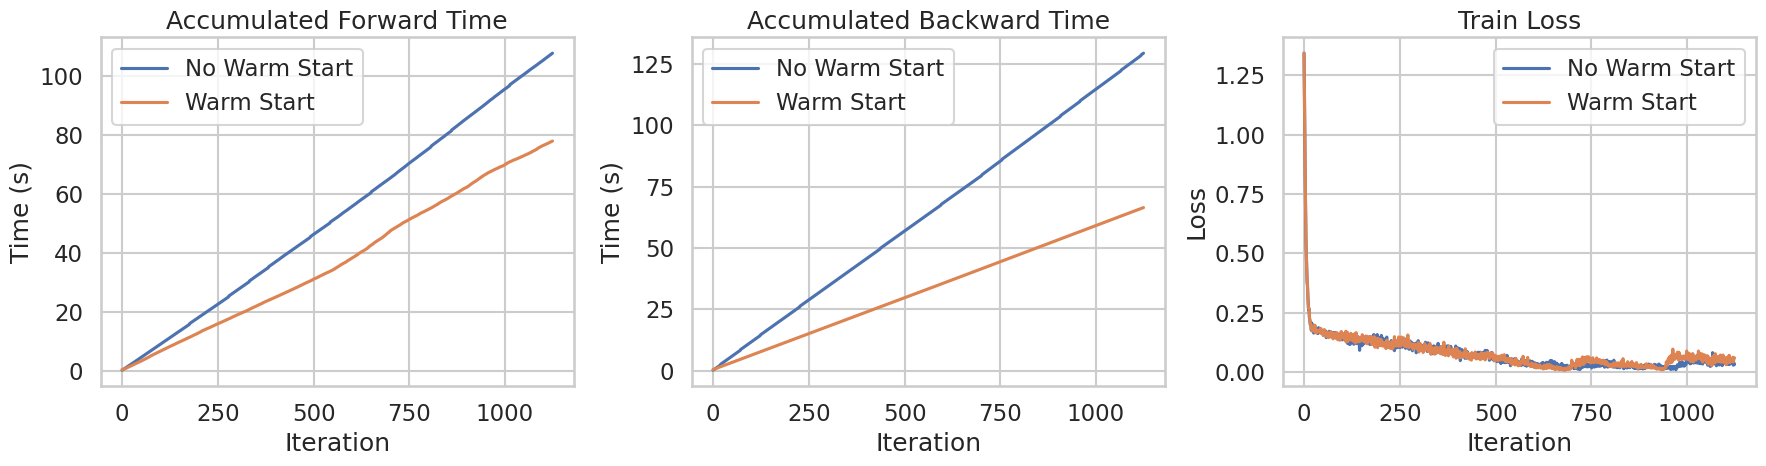

In [11]:
df = pd.concat([df_ws, df_no_ws], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cond, grp in df.groupby("condition"):
    axes[0].plot(grp["iter"], grp["accum_fwd_time"], label=cond)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Accumulated Forward Time")
axes[0].legend()

for cond, grp in df.groupby("condition"):
    axes[1].plot(grp["iter"], grp["accum_bwd_time"], label=cond)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Accumulated Backward Time")
axes[1].legend()

for cond, grp in df.groupby("condition"):
    axes[2].plot(grp["iter"], grp["train_loss"], label=cond)
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Loss")
axes[2].set_title("Train Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
summary = df.groupby("condition").agg(
    total_fwd_time=("accum_fwd_time", "last"),
    total_bwd_time=("accum_bwd_time", "last"),
    final_loss=("train_loss", "last"),
    mean_fwd_per_iter=("fwd_time", "mean"),
    mean_bwd_per_iter=("bwd_time", "mean"),
)
summary["total_time"] = summary["total_fwd_time"] + summary["total_bwd_time"]
summary

,total_fwd_time,total_bwd_time,final_loss,mean_fwd_per_iter,mean_bwd_per_iter,total_time
condition,,,,,,
No Warm Start,107.926803,129.445601,0.031281,0.095935,0.115063,237.372404
Warm Start,78.050950,66.461704,0.059254,0.069379,0.059077,144.512654
